# Phase 5 — Baseline & Ensemble Models
Competition: Playground Series S6E7 — Predicting Student Health Risk  
Metric: **Balanced accuracy** (average per-class recall)

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from src.data_prep import load_data, split_data, get_column_types
from src.features import fit_and_save_preprocessor
from src.train import train_logistic, cross_validate, save_model
from src.evaluate import evaluate_sklearn, plot_confusion_matrix
from sklearn.ensemble import RandomForestClassifier

## 1. Load & split data

In [2]:
train_df, test_df = load_data('../data/raw')
X_train, X_val, y_train, y_val = split_data(train_df)

print('Train size:', X_train.shape)
print('Val size:  ', X_val.shape)

print('\nClass balance (train):')
print(y_train.value_counts(normalize=True).round(3))

Train size: (552070, 13)
Val size:   (138018, 13)

Class balance (train):
health_condition
at-risk      0.859
unhealthy    0.084
fit          0.058
Name: proportion, dtype: float64


## 2. Build & fit preprocessing pipeline

In [3]:
numeric_cols, categorical_cols = get_column_types(X_train)
print('Numeric cols:    ', numeric_cols)
print('Categorical cols:', categorical_cols)

preprocessor = fit_and_save_preprocessor(
    X_train, numeric_cols, categorical_cols,
    save_path='../models/preprocessor.pkl'
)

X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
print('Processed shape:', X_train_proc.shape)

Numeric cols:     ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical cols: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


Preprocessor saved -> ../models/preprocessor.pkl


Processed shape: (552070, 25)


## 3. Logistic Regression — baseline


-- Logistic Regression --
Balanced accuracy: 0.8574


              precision    recall  f1-score   support

     at-risk       0.98      0.78      0.87    118512
         fit       0.38      0.90      0.53      7961
   unhealthy       0.42      0.89      0.57     11545

    accuracy                           0.80    138018
   macro avg       0.59      0.86      0.66    138018
weighted avg       0.90      0.80      0.83    138018



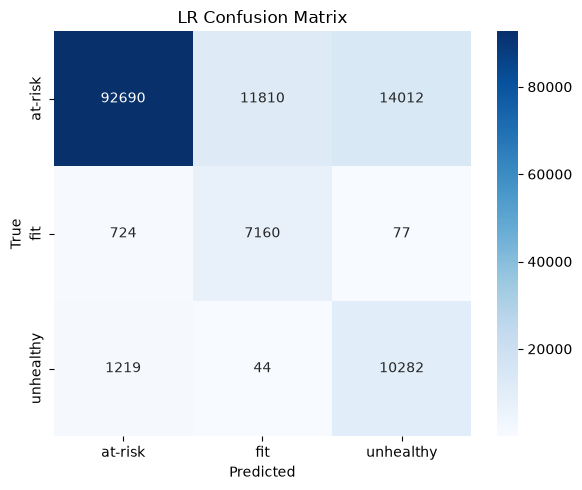

In [4]:
lr = train_logistic(X_train_proc, y_train)
lr_bal_acc, lr_preds = evaluate_sklearn(lr, X_val_proc, y_val, 'Logistic Regression')
plot_confusion_matrix(y_val, lr_preds, lr.classes_, title='LR Confusion Matrix')

## 4. Random Forest (tuned — GridSearchCV skipped, use known best params)


-- Random Forest (tuned) --
Balanced accuracy: 0.8938


              precision    recall  f1-score   support

     at-risk       0.98      0.95      0.97    118512
         fit       0.74      0.86      0.79      7961
   unhealthy       0.76      0.87      0.81     11545

    accuracy                           0.94    138018
   macro avg       0.82      0.89      0.86    138018
weighted avg       0.95      0.94      0.94    138018



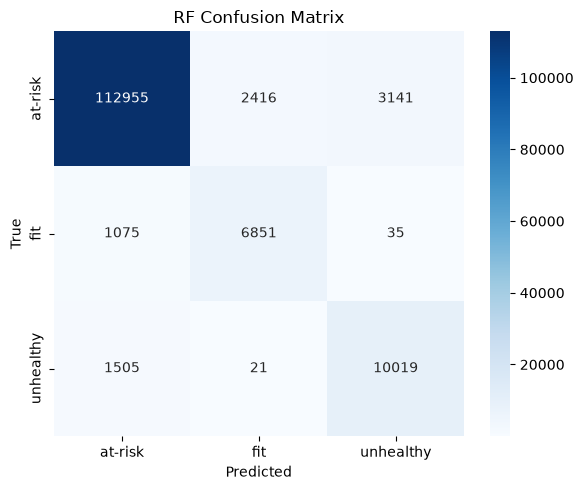

In [5]:
best_rf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
best_rf.fit(X_train_proc, y_train)
rf_bal_acc, rf_preds = evaluate_sklearn(best_rf, X_val_proc, y_val, 'Random Forest (tuned)')
plot_confusion_matrix(y_val, rf_preds, best_rf.classes_, title='RF Confusion Matrix')

## 5. Cross-validate best candidate

In [6]:
cv_scores = cross_validate(best_rf, X_train_proc, y_train, cv=3)
print(f'RF CV balanced accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV balanced accuracy: 0.8930 ± 0.0011
RF CV balanced accuracy: 0.8930 ± 0.0011


## 6. Results summary

In [7]:
results = pd.DataFrame([
    {'Model': 'LogisticRegression (balanced)', 'Val balanced_acc': lr_bal_acc, 'CV mean': '-', 'CV std': '-', 'Notes': 'baseline'},
    {'Model': 'RandomForest (tuned, balanced)', 'Val balanced_acc': rf_bal_acc, 'CV mean': round(cv_scores.mean(),4), 'CV std': round(cv_scores.std(),4), 'Notes': str(best_rf.get_params())},
])
print(results.to_markdown(index=False))
results.to_csv('../models/results_so_far.csv', index=False)

| Model                          |   Val balanced_acc | CV mean   | CV std   | Notes                                                                                                                                                                                                                                                                                                                                                                                                                             |
|:-------------------------------|-------------------:|:----------|:---------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| 

## 7. Save best sklearn model so far

In [8]:
# Save whichever is better
best_model = best_rf if rf_bal_acc >= lr_bal_acc else lr
save_model(best_model, '../models/model_final.pkl')
print('Saved model type:', type(best_model).__name__)

Model saved -> ../models/model_final.pkl
Saved model type: RandomForestClassifier
